# Project 1: Customer Churn Prediction - Intermediate Phase

## 1. Setup and Data Loading
* **Objective:** Load the cleaned dataset prepared in the previous notebook.
* **Libraries:** Import necessary libraries (pandas, numpy, matplotlib, seaborn, sklearn).

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [110]:
# Loading the cleaned dataset
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')

## 2. Feature Engineering
We will create new features to help the model distinguish patterns better.
* **Tenure Grouping:** Categorize tenure into groups (e.g., 'New', 'Loyal').
* **Service Count:** Count the total number of services a user has subscribed to.

In [111]:
# Categorizing 'tenure' into bins ('New' for (0-12 months), 'Established' for (13-24 months), 'Loyal' for (25+ months))
df['tenure_category'] = pd.cut(df['tenure'], 
                               bins=[0, 12, 24, float('inf')], 
                               labels=['New', 'Established', 'Loyal'])

# Display the first few rows of the updated dataframe
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_category
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Loyal
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Loyal
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


In [112]:
# Counting the total number of services a user has subscribed to
service_columns = ['PhoneService', 'InternetService', 'OnlineSecurity', 
                   'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                   'StreamingTV', 'StreamingMovies']
# If No service is represented as 'No' or 'None', we convert them to 0, and 'Yes' to 1
for col in service_columns:
    df[col] = df[col].apply(lambda x: 1 if x in ['Yes'] else 0)

# Counting the number of services
df['total_services'] = df[service_columns].sum(axis=1)
# Display the first few rows of the updated dataframe
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_category,total_services
0,Female,0,Yes,No,1,0,No phone service,0,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,1
1,Male,0,No,No,34,1,No,0,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,No,Loyal,3
2,Male,0,No,No,2,1,No,0,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,3
3,Male,0,No,No,45,0,No phone service,0,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,Loyal,3
4,Female,0,No,No,2,1,No,0,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,1


In [113]:
# Replacing target variable 'Churn' with binary values
df['Churn_Yes'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df.drop('Churn', axis=1, inplace=True)

# One-Hot Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)

# Display the first few rows of the final dataframe
df.head()

,SeniorCitizen,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,total_services,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_category_Established,tenure_category_Loyal
0,0,1,0,0,0,1,0,0,0,0,29.85,29.85,1,0,False,True,False,True,False,False,False,True,False,True,False,False,False
1,0,34,1,0,1,0,1,0,0,0,56.95,1889.50,3,0,True,False,False,False,False,True,False,False,False,False,True,False,True
2,0,2,1,0,1,1,0,0,0,0,53.85,108.15,3,1,True,False,False,False,False,False,False,True,False,False,True,False,False
3,0,45,0,0,1,0,1,1,0,0,42.30,1840.75,3,0,True,False,False,True,False,True,False,False,False,False,False,False,True
4,0,2,1,0,0,0,0,0,0,0,70.70,151.65,1,1,False,False,False,False,False,False,False,True,False,True,False,False,False


In [114]:
# Splitting the dataset into features and target variable
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

## 3. Handling Imbalanced Data (SMOTE)
Since the target class 'Churn' is imbalanced, we will use SMOTE (Synthetic Minority Over-sampling Technique) to balance the training set.
* **Split Data:** Train/Test split.
* **Apply SMOTE:** Apply oversampling **only** to the training data to prevent data leakage.

In [115]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [116]:
# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Before SMOTE, counts of label '1': {}".format(sum(y_train==1)))
print("Before SMOTE, counts of label '0': {} \n".format(sum(y_train==0)))
print("After SMOTE, counts of label '1': {}".format(sum(y_train_res==1)))
print("After SMOTE, counts of label '0': {}".format(sum(y_train_res==0)))

Before SMOTE, counts of label '1': 1495
Before SMOTE, counts of label '0': 4130 

After SMOTE, counts of label '1': 4130
After SMOTE, counts of label '0': 4130


## 4. Model Training and Comparison
We will train advanced tree-based models and compare them with the baseline.
* **Random Forest Classifier:** A robust ensemble method using bagging.
* **Gradient Boosting (XGBoost/LightGBM):** Advanced boosting algorithms.

In [117]:
# Training the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [118]:
# Training the XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_classifier.fit(X_train_res, y_train_res)

c:\Users\bedoo\Desktop\Projects\customer-churn-prediction\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:46:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 5. Model Evaluation
Evaluate the models using metrics that focus on the minority class.
* **Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC.
* **Confusion Matrix:** Visualize predictions.

In [119]:
# Evaluating the models on the test set

# Random Forest Evaluation
y_pred_rf = rf_classifier.predict(X_test)
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, rf_classifier.predict_proba(X_test)[:,1]))

# XGBoost Evaluation
y_pred_xgb = xgb_classifier.predict(X_test)
print("\nXGBoost Classifier Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_classifier.predict_proba(X_test)[:,1]))



Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.57      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

Confusion Matrix:
[[873 160]
 [160 214]]
ROC AUC Score: 0.8080910178028794

XGBoost Classifier Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1033
           1       0.55      0.59      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407

Confusion Matrix:
[[851 182]
 [155 219]]
ROC AUC Score: 0.8114313225070016


## 6. Feature Importance & Interpretation
To understand the driving factors behind customer churn, we will analyze the feature importance scores from our tree-based models.
* **Visualizing Importance:** We will plot the top 10 most influential features.
* **Business Insight:** This helps us understand *why* the model thinks a customer will leave (e.g., is it the Contract type or the Monthly Charges?).

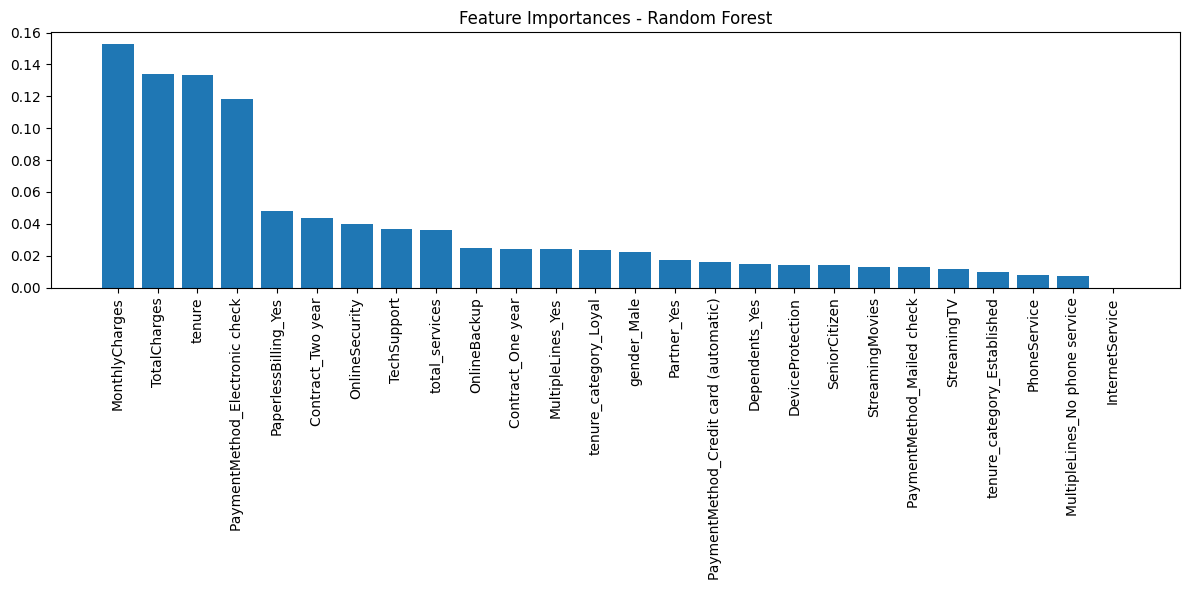

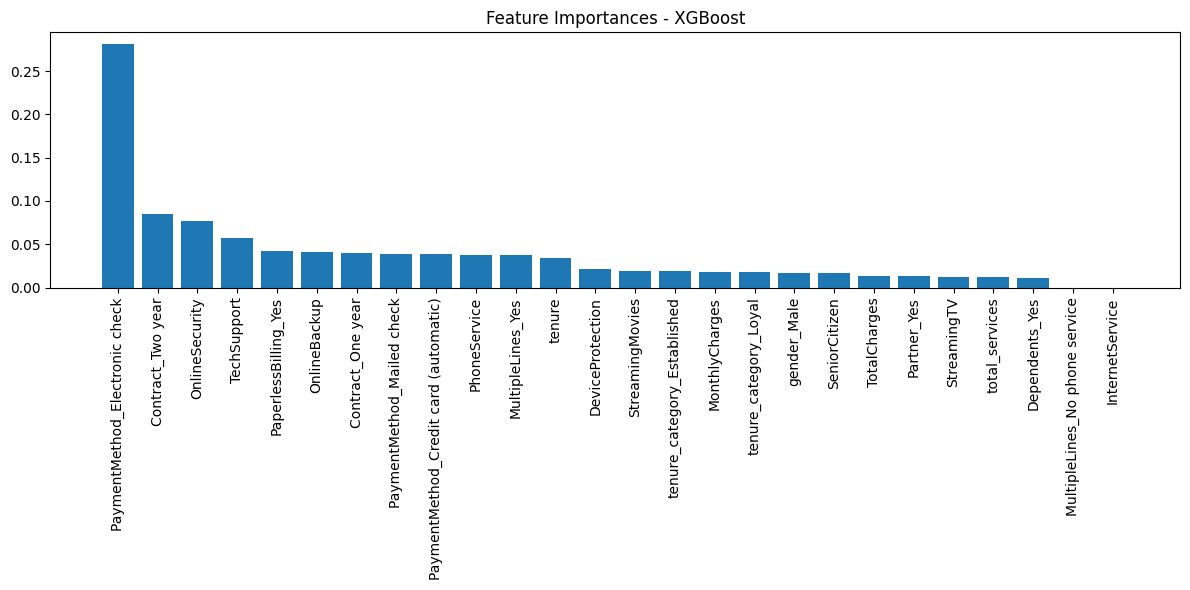

In [120]:
# Visualizing feature importance for Random Forest
importances_rf = rf_classifier.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X.shape[1]), importances_rf[indices_rf], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices_rf], rotation=90)
plt.tight_layout()
plt.show()

# Visualizing feature importance for XGBoost
importances_xgb = xgb_classifier.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances - XGBoost")
plt.bar(range(X.shape[1]), importances_xgb[indices_xgb], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning
We will now optimize our best-performing models to improve the Recall score.
* **Method:** We will use `RandomizedSearchCV` (faster than GridSearch) to find the best combination of parameters.
* **Focus:** We will specifically tune parameters that handle class imbalance (e.g., `class_weight` for RF, `scale_pos_weight` for XGBoost).

In [127]:
from scipy.stats import uniform, randint
# XGBoost Hyperparameter Tuning using GridSearchCV

# Scale_pos_weight helps to handle class imbalance in XGBoost. We will use general formula (number of negative samples / number of positive samples) for better tuning.
# According to that formula: , scale_pos_weight = 5174 / 1869 ≈ 2.77. We will try values around this. (2, 2.35, 2.77, 3, 3.5)


neg_pos_ratio = sum(y_train_res == 0) / sum(y_train_res == 1)

xgb_param_grid = {
    'n_estimators': randint(100,300),       # between 100 and 299
    'max_depth': randint(3,8),              # between 3 and 7
    'learning_rate': uniform(0.01, 0.2),    # between 0.01 and 0.21
    'subsample': uniform(0.8, 0.2),         # between 0.8 and 1.0
    'colsample_bytree': uniform(0.8, 0.2),  # between 0.8 and 1.0
    'scale_pos_weight': [2.0, 2.35, neg_pos_ratio, 3.0, 3.5]  # around the calculated ratio
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_classifier,           # XGBoost classifier
    param_distributions=xgb_param_grid, # parameter distributions
    n_iter=20,                          # number of parameter settings that are sampled
    scoring='recall',                   # scoring metric
    cv=5,                               # cross-validation folds
    n_jobs=-1,                          # parallel jobs
    verbose=2,                           # verbosity level
    random_state=42                     # for reproducibility
    )

In [128]:
# Training RandomizedSearchCV for XGBoost
xgb_random_search.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\bedoo\Desktop\Projects\customer-churn-prediction\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:50:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....001C866193750>, 'learning_rate': <scipy.stats....001C867664A10>, 'max_depth': <scipy.stats....001C841CAEBE0>, 'n_estimators': <scipy.stats....001C844D01D90>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guid

In [129]:
# Evaluating the best models from RandomizedSearchCV on the test set
best_xgb_model = xgb_random_search.best_estimator_

# Disyplaying best parameters
print("Best XGBoost Parameters:", xgb_random_search.best_params_)

# Displaying best recall score
print("Best XGBoost Recall Score:", xgb_random_search.best_score_)

# Evaluating the best XGBoost model
y_pred_best_xgb = best_xgb_model.predict(X_test)
print("\nBest XGBoost Classifier Report:")
print(classification_report(y_test, y_pred_best_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, best_xgb_model.predict_proba(X_test)[:,1]))


Best XGBoost Parameters: {'colsample_bytree': np.float64(0.821578285398661), 'learning_rate': np.float64(0.01628583713734685), 'max_depth': 3, 'n_estimators': 151, 'scale_pos_weight': 3.5, 'subsample': np.float64(0.9017141382329406)}
Best XGBoost Recall Score: 0.9569007263922519

Best XGBoost Classifier Report:
              precision    recall  f1-score   support

           0       0.94      0.50      0.66      1033
           1       0.40      0.92      0.56       374

    accuracy                           0.61      1407
   macro avg       0.67      0.71      0.61      1407
weighted avg       0.80      0.61      0.63      1407

Confusion Matrix:
[[519 514]
 [ 31 343]]
ROC AUC Score: 0.824795129703734


In [130]:
# Random Forest Hyperparameter Tuning using RandomizedSearchCV
from scipy.stats import uniform, randint

# Random Forest Hyperparameter Grid
rf_param_grid = {
    'n_estimators': randint(100, 500),      # number of trees in the forest
    'max_depth': [10, 20, 30, 40, None],    # maximum depth of the tree
    'min_samples_split': [2, 5, 10],        # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],          # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'],       # number of features to consider when looking for the best split
    'bootstrap': [True, False],             # whether bootstrap samples are used when building trees
    'class_weight': ['balanced', 'balanced_subsample', None]  # handling class imbalance
}   

rf_base = RandomForestClassifier(random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,                 # Random Forest classifier
    param_distributions=rf_param_grid, # parameter distributions
    n_iter=20,                        # number of parameter settings that are sampled
    scoring='recall',                 # scoring metric
    cv=5,                             # cross-validation folds
    n_jobs=-1,                        # parallel jobs
    verbose=2,                       # verbosity level
    random_state=42                   # for reproducibility
    )

In [131]:
# Training RandomizedSearchCV for Random Forest
rf_random_search.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [132]:
# Evaluating the best Random Forest model
best_rf_model = rf_random_search.best_estimator_

# Displaying best parameters
print("Best Random Forest Parameters:", rf_random_search.best_params_)

# Displaying best recall score
print("Best Random Forest Recall Score:", rf_random_search.best_score_)

y_pred_best_rf = best_rf_model.predict(X_test)
print("Best Random Forest Classifier Report:")
print(classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))
print("ROC AUC Score:", roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:,1]))

Best Random Forest Parameters: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 352}
Best Random Forest Recall Score: 0.8421307506053269
Best Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.66      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407

Confusion Matrix:
[[831 202]
 [129 245]]
ROC AUC Score: 0.8272618560757049


In [133]:
import joblib
import os

# File paths to save the models
model_dir = '../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    
# Saving he random forest model
best_rf_model = rf_random_search.best_estimator_
joblib.dump(best_rf_model, os.path.join(model_dir, 'rf_intermediate_model.joblib'))

# Saving the XGBoost model
best_xgb_model = xgb_random_search.best_estimator_
joblib.dump(best_xgb_model, os.path.join(model_dir, 'xgb_intermediate_model.joblib'))

print("Models saved successfully.")

Models saved successfully.


## 8. Threshold Tuning (Precision-Recall Trade-off)
The default decision threshold is 0.5. Since our model is aggressive (high Recall, low Precision), we will adjust this threshold to find a better balance.
* **Precision-Recall Curve:** Visualize how metrics change at different thresholds.
* **Optimal Threshold:** Find the threshold that maximizes the F1-Score (harmonic mean of Precision and Recall).

Best Threshold for F1 Score: 0.72252566
Best F1 Score: 0.6074074073595803


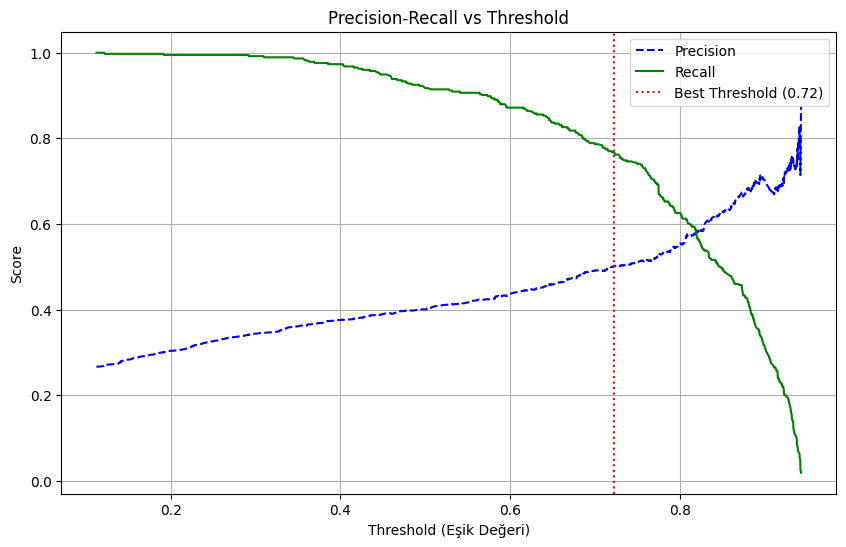

In [ ]:
# Taking the probabilities for Class 1 (Churn)
from sklearn.metrics import precision_recall_curve


y_pred_proba = best_xgb_model.predict_proba(X_test)[:,1]

# Calculating Precision, Recall and Thresholds for Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculating F1 scores for each threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)  # Adding small value to avoid division by zero

# Finding the threshold that gives the maximum F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold for F1 Score:", best_threshold)
print("Best F1 Score:", best_f1)

# Graph
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.axvline(x=best_threshold, color='r', linestyle=':', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel("Threshold (Eşik Değeri)")
plt.ylabel("Score")
plt.legend(loc="best")
plt.title("Precision-Recall vs Threshold")
plt.grid(True)
plt.show()